In [3]:
###############
from md_Helpers.run_logs import configure_run_logging

configure_run_logging(
    True,
    notebook_name="Checker",
)
###############

PosixPath('/exp/e961/data/MDsims-data/pnichols/run_logs/Checker_2026-07-22_19-04-28_253917.log')

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.800/kT_1.000/nsteps_1000000/seed_1/randomization.gsd
created_new: False
log_path: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.800/kT_1.000/nsteps_1000000/seed_1/randomization_log.hdf5
state_path: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.800/kT_1.000/nsteps_1000000/seed_1/randomization.gsd


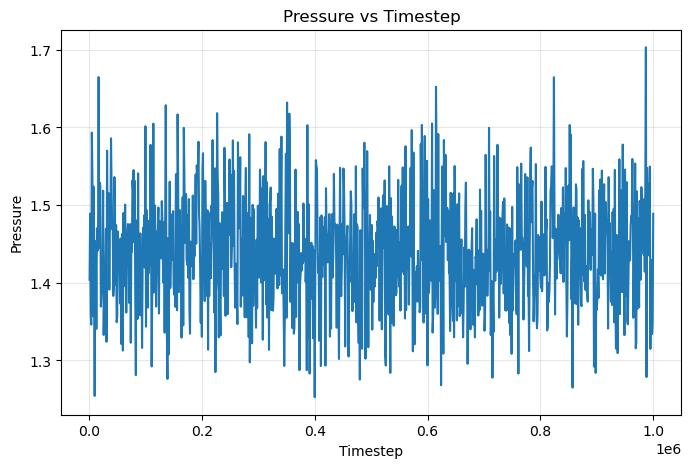

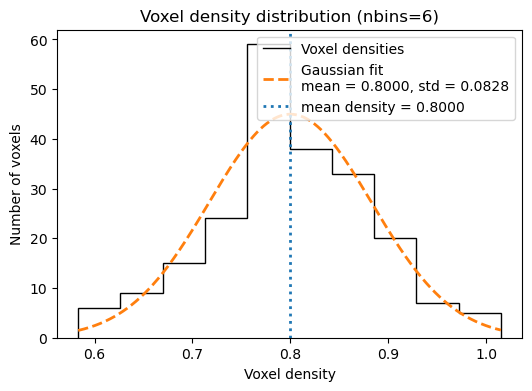

Voxel density summary
nbins:              6
number of voxels:   216
voxel volume:       23.148150539243517
mean density:       0.7999999173637526
std density:        0.08280520867354511
min density:        0.604799937526997
max density:        0.9935998973657807


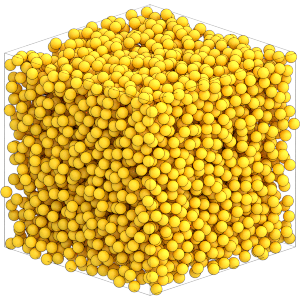

In [4]:
from pathlib import Path
import importlib

from md_Helpers import simulation as sim
from md_Helpers import runs as runs
from md_Helpers import metadata
from md_Helpers import visualization as viz
from md_Helpers import classification


importlib.reload(sim)
importlib.reload(runs)
importlib.reload(metadata)
importlib.reload(viz)
importlib.reload(classification)

# Small test example. Increase n_fcc_cells/nsteps for production.
result = sim.get_or_make_thermalized_state(
    n_fcc_cells=10,
    target_rho=0.8,
    kT=1.00,
    nsteps=1_000_000,
    phase_name="randomization",
    overwrite=False,
    overwrite_lattice=False,
)

log_path = Path(result["paths"]["log_path"])
state_path = Path(result["paths"]["state_path"])

print("created_new:", result["created_new"])
print("log_path:", log_path)
print("state_path:", state_path)

# Plot logs
log = runs.read_hdf5_log(log_path)
viz.plot_log_quantity(log, "pressure")

viz.plot_voxel_histogram(result,nbins=6);
viz.render(result)

In [8]:
from pprint import pprint

# ============================================================
# Read v3 metadata stored in the log
# ============================================================

metadata_groups = [
    "metadata/state",
    "metadata/run",
    "metadata/lj",
    "metadata/paths",
    "metadata/source",
    "metadata/classification/phase_separation",
    "metadata/classification/phase_separation/voxel",
    "metadata/classification/phase_separation/PE_drop",
]

all_metadata = {}

for group_path in metadata_groups:
    attrs = metadata.read_attrs(
        log_path,
        group_path,
    )

    if not attrs:
        continue

    all_metadata[group_path] = attrs

    print("\n" + "=" * 80)
    print(group_path)
    print("=" * 80)

    pprint(
        attrs,
        sort_dicts=False,
    )

# all_metadata is also available for programmatic access.


metadata/state
{'BoxLength': 18.325206756591797,
 'N': 4000,
 'actual_rho': 0.6499999771101618,
 'data_version': 'v3',
 'density_mode': 'fixed_N_variable_L',
 'fcc_cell_size': 1.8325206756591796,
 'kT': 1.05,
 'lattice_type': 'fcc',
 'n_fcc_cells': 10,
 'state_kind': 'thermalized',
 'target_rho': 0.65,
 'volume': 6153.846370554689}

metadata/run
{'dt': 0.005,
 'final_timestep': 1000000,
 'log_period': 1000,
 'nsteps': 1000000,
 'phase_name': 'randomization',
 'run_kind': 'thermalization',
 'seed': 1}

metadata/lj
{'buffer_LJ': 0.4,
 'epsilon_LJ': 1.0,
 'lj_mode': 'xplor',
 'r_cut_LJ': 2.5,
 'r_on_LJ': 2.0,
 'sigma_LJ': 1.0}

metadata/paths
{'log_path': '/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.650/kT_1.050/nsteps_1000000/seed_1/randomization_log.hdf5',
 'state_path': '/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.650/kT_1.050/nsteps_1000000/seed_1/randomization.gsd'}

metadata/source
{'starting_state_path': '/exp/e